# 04 - GEE source matrix demo (Moscardo catchment)

This notebook demonstrates all datasets currently supported by `geomorphconn.gee.GEEFetcher` for the Moscardo catchment (Italian Alps), and compares rainfall grid resolution options available in GEE for Europe.

## 1) Configuration

- Catchment: Moscardo (Italian Alps)
- Bounds format: `(lon_min, lat_min, lon_max, lat_max)`
- CRS is projected (UTM 33N) so slope/routing use metric x/y units

In [26]:
from pathlib import Path

# Moscardo catchment, Italian Alps
BOUNDS = (13.005143, 46.557315, 13.052346, 46.583893)

# Use projected CRS in meters for robust slope/routing calculations
CRS = "EPSG:32633"

# Date window chosen so all NDVI sensors (including Landsat 9) are available
START_DATE = "2022-06-01"
END_DATE = "2022-09-30"

# Core fetch scale for DEM/NDVI target grid
SCALE = 30

# Replace with your own Earth Engine project if required
GEE_PROJECT = "drylands-aberuni"

OUTPUT_DIR = Path("output_nb4")
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR

WindowsPath('output_nb4')

In [39]:
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geomorphconn.gee import GEEFetcher

print("Supported source keys from fetcher:")
GEEFetcher.list_sources()

Supported source keys from fetcher:
DEM sources:         ['SRTM', 'COPDEM30', 'MERIT']
Rainfall sources:    ['CHIRPS', 'ERA5', 'PERSIANN']
NDVI sources:        ['SENTINEL2', 'LANDSAT8', 'LANDSAT9']
Land-cover sources:  ['WORLDCOVER', 'WORLDCOVER_V100', 'MODIS_LC']


## 2) Helper: fetch one combo and summarize outputs

In [40]:
def summarize_array(name, arr):
    return {
        f"{name}_shape": tuple(arr.shape),
        f"{name}_min": float(np.nanmin(arr)),
        f"{name}_max": float(np.nanmax(arr)),
        f"{name}_mean": float(np.nanmean(arr)),
    }


def fetch_combo(dem_source, rainfall_source, ndvi_source, landcover_source=None):
    t0 = time.perf_counter()
    try:
        fetcher = GEEFetcher(
            bounds=BOUNDS,
            dem_source=dem_source,
            rainfall_source=rainfall_source,
            ndvi_source=ndvi_source,
            landcover_source=landcover_source,
            start_date=START_DATE,
            end_date=END_DATE,
            scale=SCALE,
            crs=CRS,
            gee_project=GEE_PROJECT,
        )

        result = fetcher.fetch()
        dem = result["dem"]
        ndvi = result["ndvi"]
        rainfall = result["rainfall"]
        profile = result["profile"]
        landcover = result.get("landcover", None)

        row = {
            "status": "ok",
            "dem_source": dem_source,
            "rainfall_source": rainfall_source,
            "ndvi_source": ndvi_source,
            "landcover_source": landcover_source,
            "crs": str(profile["crs"]),
            "dx": float(abs(profile["transform"].a)),
            "runtime_s": round(time.perf_counter() - t0, 2),
        }
        row.update(summarize_array("dem", dem))
        row.update(summarize_array("ndvi", ndvi))
        row.update(summarize_array("rainfall", rainfall))

        if landcover is not None:
            unique = np.unique(landcover[landcover >= 0])
            row["landcover_unique_count"] = int(unique.size)

        return row, result

    except Exception as exc:
        return {
            "status": "error",
            "dem_source": dem_source,
            "rainfall_source": rainfall_source,
            "ndvi_source": ndvi_source,
            "landcover_source": landcover_source,
            "error": str(exc),
            "runtime_s": round(time.perf_counter() - t0, 2),
        }, None


def map_extent_from_profile(profile):
    tr = profile["transform"]
    width = profile["width"]
    height = profile["height"]
    xmin = tr.c
    xmax = tr.c + width * tr.a
    ymax = tr.f
    ymin = tr.f + height * tr.e
    return [xmin, xmax, ymin, ymax]


def plot_source_maps(results_dict, array_key, title, cmap="viridis", categorical=False):
    valid = [(name, out) for name, out in results_dict.items() if out is not None]
    if not valid:
        print(f"No successful outputs available for {array_key} maps.")
        return

    n = len(valid)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=110, squeeze=False)
    axes = axes.ravel()

    for ax, (name, out) in zip(axes, valid):
        arr = out[array_key]
        extent = map_extent_from_profile(out["profile"])
        if categorical:
            masked = np.where(arr < 0, np.nan, arr)
            im = ax.imshow(masked, cmap=cmap, interpolation="nearest", extent=extent)
        else:
            im = ax.imshow(arr, cmap=cmap, interpolation="nearest", extent=extent)
        ax.set_title(name)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.suptitle(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 3) DEM sources (SRTM, COPDEM30, MERIT)

Rainfall and NDVI kept fixed to isolate DEM differences.

In [41]:
DEM_SOURCES = ["SRTM", "COPDEM30", "MERIT"]
rows_dem = []
results_dem = {}

for ds in DEM_SOURCES:
    row, out = fetch_combo(ds, "CHIRPS", "SENTINEL2")
    rows_dem.append(row)
    results_dem[ds] = out

df_dem = pd.DataFrame(rows_dem)
df_dem

GEEFetcher configured:
  DEM        : SRTM 1 arc-second (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 746.0–2030.0 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
GEEFetcher configured:
  DEM        : MERIT Hydrologically Conditi

,status,dem_source,rainfall_source,ndvi_source,landcover_source,crs,dx,runtime_s,dem_shape,dem_min,dem_max,dem_mean,ndvi_shape,ndvi_min,ndvi_max,ndvi_mean,rainfall_shape,rainfall_min,rainfall_max,rainfall_mean
0,ok,SRTM,CHIRPS,SENTINEL2,None,EPSG:32633,30.0,3.72,"(95, 123)",746.000000,2030.000000,1341.568250,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525
1,ok,COPDEM30,CHIRPS,SENTINEL2,None,EPSG:32633,30.0,4.31,"(95, 123)",736.412231,2039.081421,1343.621950,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525
2,ok,MERIT,CHIRPS,SENTINEL2,None,EPSG:32633,30.0,3.92,"(95, 123)",750.241821,2023.218628,1334.954522,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525


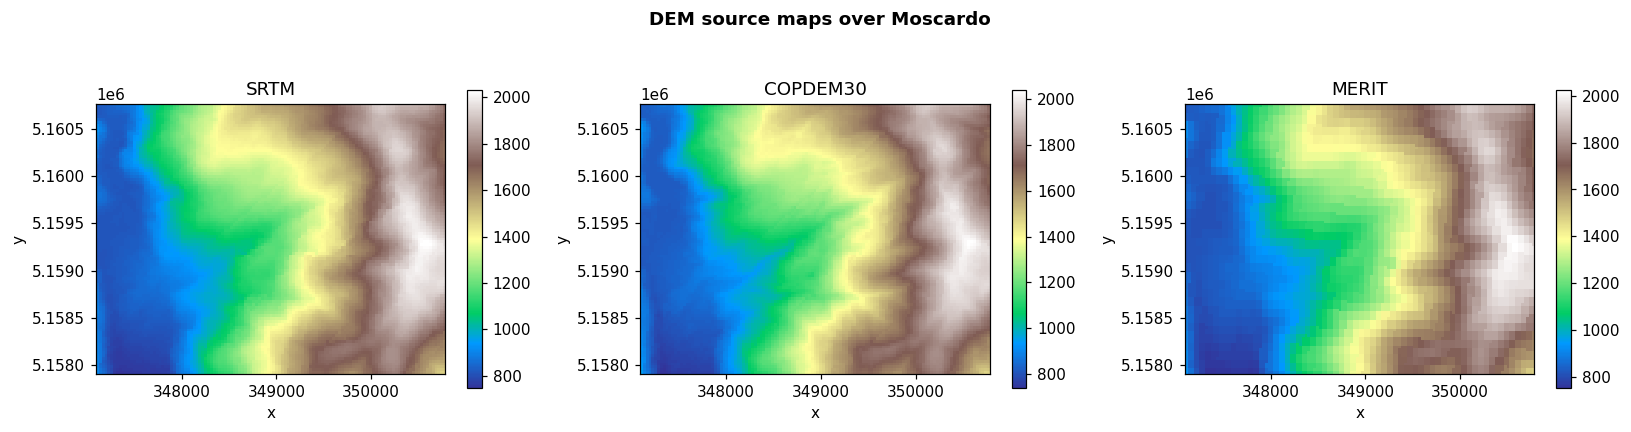

In [42]:
plot_source_maps(
    results_dem,
    array_key="dem",
    title="DEM source maps over Moscardo",
    cmap="terrain",
)

## 4) NDVI sources (SENTINEL2, LANDSAT8, LANDSAT9)

DEM and rainfall kept fixed to isolate NDVI differences.

In [43]:
NDVI_SOURCES = ["SENTINEL2", "LANDSAT8", "LANDSAT9"]
rows_ndvi = []
results_ndvi = {}

for ns in NDVI_SOURCES:
    row, out = fetch_combo("COPDEM30", "CHIRPS", ns)
    rows_ndvi.append(row)
    results_ndvi[ns] = out

df_ndvi = pd.DataFrame(rows_ndvi)
df_ndvi

GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Landsat 8 Collection 2 SR (~30 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.021–0.533
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (

,status,dem_source,rainfall_source,ndvi_source,landcover_source,crs,dx,runtime_s,dem_shape,dem_min,dem_max,dem_mean,ndvi_shape,ndvi_min,ndvi_max,ndvi_mean,rainfall_shape,rainfall_min,rainfall_max,rainfall_mean
0,ok,COPDEM30,CHIRPS,SENTINEL2,None,EPSG:32633,30.0,3.61,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525
1,ok,COPDEM30,CHIRPS,LANDSAT8,None,EPSG:32633,30.0,3.87,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.021094,0.532505,0.344332,"(95, 123)",438.47525,438.47525,438.47525
2,ok,COPDEM30,CHIRPS,LANDSAT9,None,EPSG:32633,30.0,3.42,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.026307,0.535707,0.323110,"(95, 123)",438.47525,438.47525,438.47525


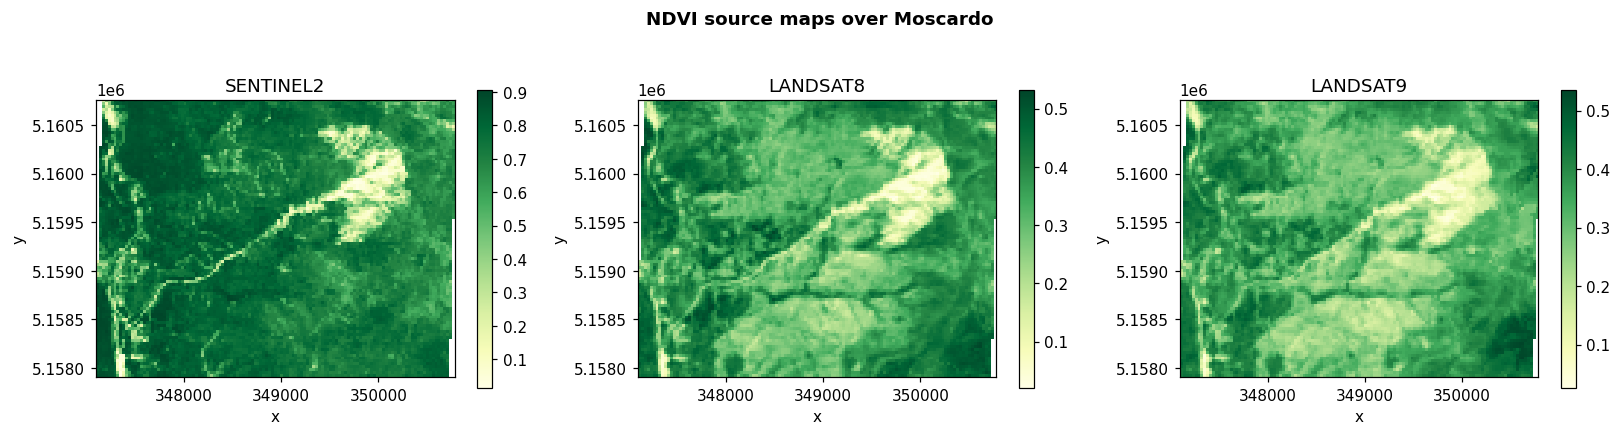

In [44]:
plot_source_maps(
    results_ndvi,
    array_key="ndvi",
    title="NDVI source maps over Moscardo",
    cmap="YlGn",
)

## 5) Rainfall sources (CHIRPS, ERA5, PERSIANN)

DEM and NDVI are kept fixed to isolate rainfall source differences.

All rainfall arrays are interpreted as accumulated precipitation over the selected period in mm.

In [45]:
RAINFALL_SOURCES = ["CHIRPS", "ERA5", "PERSIANN"]
rows_rf = []
results_rf = {}

for rs in RAINFALL_SOURCES:
    row, out = fetch_combo("COPDEM30", rs, "SENTINEL2")
    rows_rf.append(row)
    results_rf[rs] = out

df_rf = pd.DataFrame(rows_rf)
df_rf

GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : ERA5-Land monthly total precipitation (~11 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : None (not fetched)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 0.18–0.18
GEEFetcher configured:
  DEM        : Copernicus DEM GLO

,status,dem_source,rainfall_source,ndvi_source,landcover_source,crs,dx,runtime_s,dem_shape,dem_min,dem_max,dem_mean,ndvi_shape,ndvi_min,ndvi_max,ndvi_mean,rainfall_shape,rainfall_min,rainfall_max,rainfall_mean
0,ok,COPDEM30,CHIRPS,SENTINEL2,None,EPSG:32633,30.0,4.28,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.475250,438.475250,438.475250
1,ok,COPDEM30,ERA5,SENTINEL2,None,EPSG:32633,30.0,4.43,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",0.183917,0.183917,0.183917
2,ok,COPDEM30,PERSIANN,SENTINEL2,None,EPSG:32633,30.0,4.02,"(95, 123)",736.412231,2039.081421,1343.62195,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",512.573120,512.573120,512.573120


## 6) Land-cover sources (optional in fetcher)

Uses `landcover_source` in `GEEFetcher` and reports number of unique classes over Moscardo.

In [46]:
# Keep only robust land-cover options for this demo; WORLDCOVER_V100 was flaky in some runs.
LANDCOVER_SOURCES = ["WORLDCOVER", "MODIS_LC", "CORINE"]
rows_lc = []
results_lc = {}

for lc in LANDCOVER_SOURCES:
    row, out = fetch_combo("COPDEM30", "CHIRPS", "SENTINEL2", landcover_source=lc)
    rows_lc.append(row)
    results_lc[lc] = out

df_lc = pd.DataFrame(rows_lc)
df_lc

GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : ESA WorldCover 10 m v200 (2021)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907
Fetching Rainfall …
  Rainfall shape: (95, 123), range: 438.48–438.48
Fetching Land Cover …
  Land cover shape: (95, 123), unique codes: [10, 30, 40, 50, 60, 80]…
GEEFetcher configured:
  DEM        : Copernicus DEM GLO-30 (~30 m)
  Rainfall   : CHIRPS daily precipitation (~5.5 km)
  NDVI       : Sentinel-2 SR Harmonized (~10 m)
  Land cover : MODIS MCD12Q1 Land Cover Type 1 IGBP (500 m)
  Period     : 2022-06-01 → 2022-09-30
  Scale      : 30 m  |  CRS: EPSG:32633
Fetching DEM …
  DEM shape: 95×123, range: 736.4–2039.1 m
Fetching NDVI …
  NDVI shape: (95, 123), range: 0.015–0.907


,status,dem_source,rainfall_source,ndvi_source,landcover_source,crs,dx,runtime_s,dem_shape,dem_min,...,ndvi_shape,ndvi_min,ndvi_max,ndvi_mean,rainfall_shape,rainfall_min,rainfall_max,rainfall_mean,landcover_unique_count,error
0,ok,COPDEM30,CHIRPS,SENTINEL2,WORLDCOVER,EPSG:32633,30.0,5.10,"(95, 123)",736.412231,...,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525,6.0,NaN
1,ok,COPDEM30,CHIRPS,SENTINEL2,MODIS_LC,EPSG:32633,30.0,4.57,"(95, 123)",736.412231,...,"(95, 123)",0.014685,0.907103,0.703929,"(95, 123)",438.47525,438.47525,438.47525,5.0,NaN
2,error,COPDEM30,CHIRPS,SENTINEL2,CORINE,NaN,NaN,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"landcover_source must be one of ['WORLDCOVER',..."


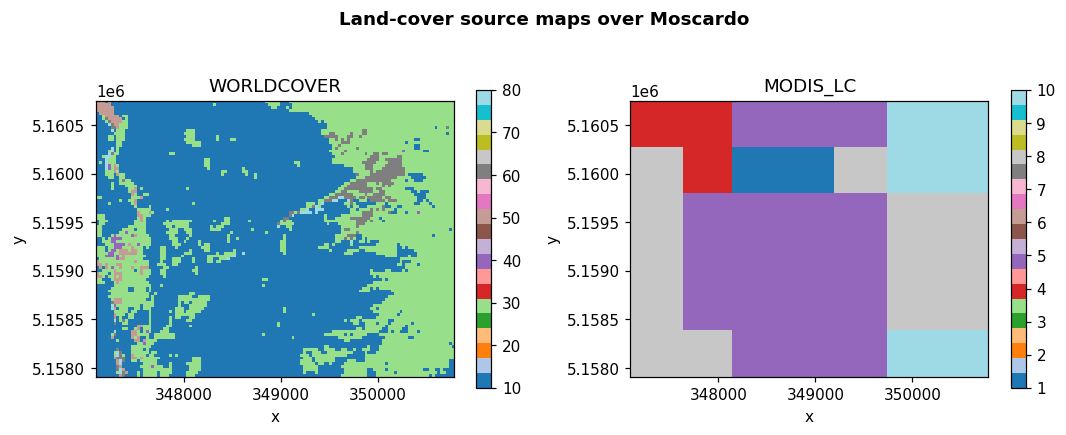

In [47]:
plot_source_maps(
    results_lc,
    array_key="landcover",
    title="Land-cover source maps over Moscardo",
    cmap="tab20",
    categorical=True,
)

## 7) Quick visual comparison for rainfall source effect

In [ ]:
results_rf['ERA5']['rainfall'] = results_rf['ERA5']['rainfall']*1000 #converting from m to mm for better interpretability in plots/tables

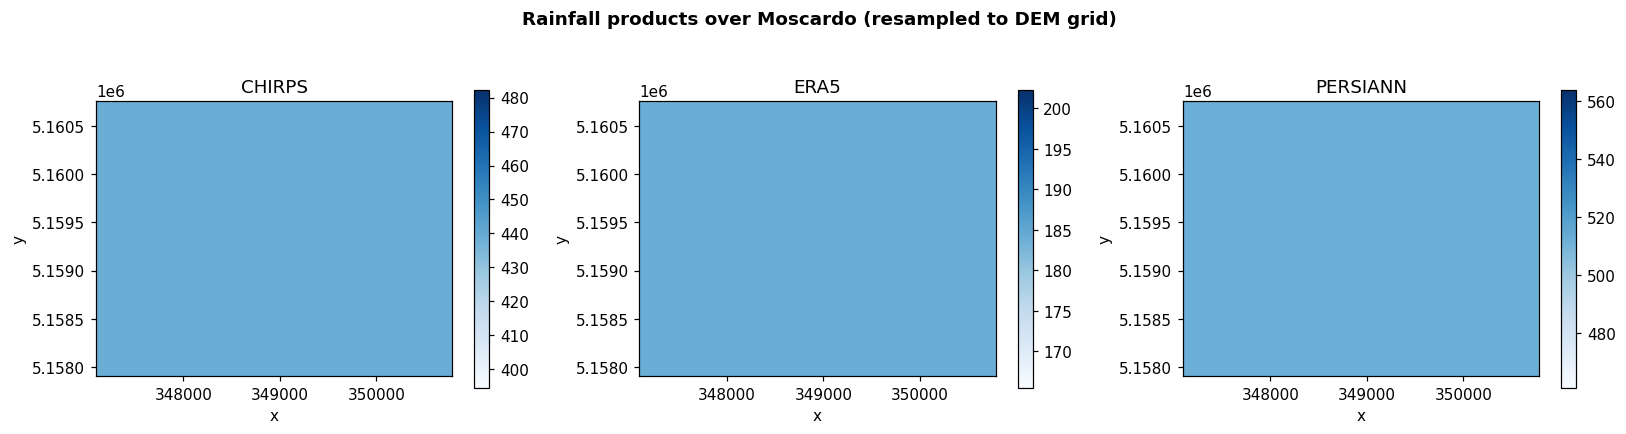

In [54]:
plot_source_maps(
    results_rf,
    array_key="rainfall",
    title="Rainfall products over Moscardo (resampled to DEM grid)",
    cmap="Blues",
)

In [50]:
# Save summary tables
df_dem.to_csv(OUTPUT_DIR / "dem_sources_summary.csv", index=False)
df_ndvi.to_csv(OUTPUT_DIR / "ndvi_sources_summary.csv", index=False)
df_rf.to_csv(OUTPUT_DIR / "rainfall_sources_summary.csv", index=False)
df_lc.to_csv(OUTPUT_DIR / "landcover_sources_summary.csv", index=False)
print("Saved CSV summaries to", OUTPUT_DIR.resolve())

Saved CSV summaries to E:\SideResearch\softwares\IndexOfConnectivity\sedconn_v3\sedconn\notebooks\output_nb4
